![Banner](../../images/05_banner.png)


# 5.2 Motivation: the Small-Area Estimation Problem

**Part:** 5 — Disease Mapping and Bayesian Smoothing (Chapter 5.2 of 11)

**Dataset:** `diabetes_northeast.shp` (217 counties)

**Focus:** Why raw small-area rates are noisier than they look, demonstrated with real numbers rather than asserted

**Library:** `spatialstats.bayes` (PySpatialStats)

***

## Table of Contents

1. [Overview](#1.-Overview)

2. [Python Setup](#2.-Python-Setup)

3. [Poisson Variability: Var(rate) ∝ 1/Population](#3.-Poisson-Variability:-Var(rate)-∝-1/Population)

4. [The Funnel Plot](#4.-The-Funnel-Plot)

5. [Consequence: Unstable Rankings](#5.-Consequence:-Unstable-Rankings)

6. [Other Consequences](#6.-Other-Consequences)

7. [The Goal: Borrowing Strength](#7.-The-Goal:-Borrowing-Strength)

8. [Summary and Conclusions](#8.-Summary-and-Conclusions)

9. [Resources](#9.-Resources)


***
## 1. Overview

A raw rate — observed cases divided by population — treats every area as if its estimate were equally precise.
It is not, and the reason is not subtle geography or data quality: it is **basic Poisson sampling theory**. This
chapter makes that mechanism concrete with the same 217 counties used throughout Parts 2–4, before Chapter 5.3
turns to the data preparation Part 5 needs and Chapters 5.5–5.7 build the fix.

| Step | What we do |
|------|------------|
| The mechanism | Derive and verify directly that a rate's sampling variance scales as $1/\text{population}$ |
| The funnel plot | The standard visual: rate against population, with control limits that shrink as population grows |
| Rankings | A concrete simulation showing how much a county's *rank* would shuffle under repeated sampling, purely from noise, split by population size |
| Other consequences | False hot spots, small-cell privacy, and how Part 2/4's cluster methods inherit this problem |
| The goal | *Borrowing strength* — across all areas (empirical Bayes, Chapter 5.5) or across neighbours (BYM, Chapter 5.6) |

***
## 2. Python Setup

In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)


def find_repo_root(start: Path = Path.cwd()) -> Path:
    for p in [start, *start.parents]:
        if (p / "pyproject.toml").exists() and (p / "data").is_dir():
            return p
    raise FileNotFoundError("Run this notebook from inside the PySpatialStats repository.")


ROOT = find_repo_root()
DATA = ROOT / "data"
try:
    import spatialstats
except ImportError:
    sys.path.insert(0, str(ROOT))
    import spatialstats

from spatialstats.bayes import expected_counts, smr, funnel_limits

plt.rcParams.update({
    "figure.dpi": 100, "savefig.dpi": 100, "font.size": 10, "axes.titlesize": 11,
    "axes.titleweight": "bold", "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "legend.frameon": False,
})
C = {"blue": "#2b6cb0", "red": "#c0392b", "green": "#2f855a", "orange": "#dd6b20",
     "grey": "#718096", "purple": "#6b46c1", "teal": "#2c7a7b"}

counties = gpd.read_file(DATA / "diabetes_northeast.shp")
O = counties["Dia_count"].to_numpy()
POP = counties["POP_Total"].to_numpy()
E = expected_counts(POP, observed=O)
print(f"spatialstats : version {spatialstats.__version__}")
print(f"population range: [{POP.min():,.0f}, {POP.max():,.0f}]  ({POP.max()/POP.min():.0f}x span)")

spatialstats : version 0.2.0
population range: [4,444, 2,591,918]  (583x span)


***
## 3. Poisson Variability: Var(rate) ∝ 1/Population

If cases occur independently at a constant true rate $p$, the observed count $O$ in a population of size $n$
is (approximately, for rare-ish outcomes) $O \sim \text{Poisson}(np)$, so the **rate** $\hat p = O/n$ has

$$
\text{Var}(\hat p) = \frac{p(1-p)}{n} \;\propto\; \frac{1}{n}.
$$

A 100-fold difference in population produces a 100-fold difference in variance — a **10-fold** difference in
standard error. This is not an assumption; it follows directly from the definition of a rate as a ratio of a
random count to a fixed denominator.

In [2]:
p = 0.08  # a representative diabetes prevalence
for pop in (5_000, 50_000, 500_000, 5_000_000):
    var_rate = p * (1 - p) / pop
    print(f"population = {pop:>10,}: Var(rate) = {var_rate:.3e}, SE = {np.sqrt(var_rate):.5f}")

population =      5,000: Var(rate) = 1.472e-05, SE = 0.00384
population =     50,000: Var(rate) = 1.472e-06, SE = 0.00121
population =    500,000: Var(rate) = 1.472e-07, SE = 0.00038
population =  5,000,000: Var(rate) = 1.472e-08, SE = 0.00012


Each 10-fold increase in population divides the standard error by exactly $\sqrt{10} \approx 3.16$ — verified
directly above (each row's SE is the previous row's divided by ≈3.16). Nothing about the *disease process*
changed across these four rows; the only thing that changed was the size of the denominator.

***
## 4. The Funnel Plot

The standard way to see this in real data: plot the SMR against $E$ (expected count, a proxy for population),
and overlay the Poisson control limits from `funnel_limits` — the "funnel" shape *is* the $1/\sqrt{E}$ scaling
made visible.

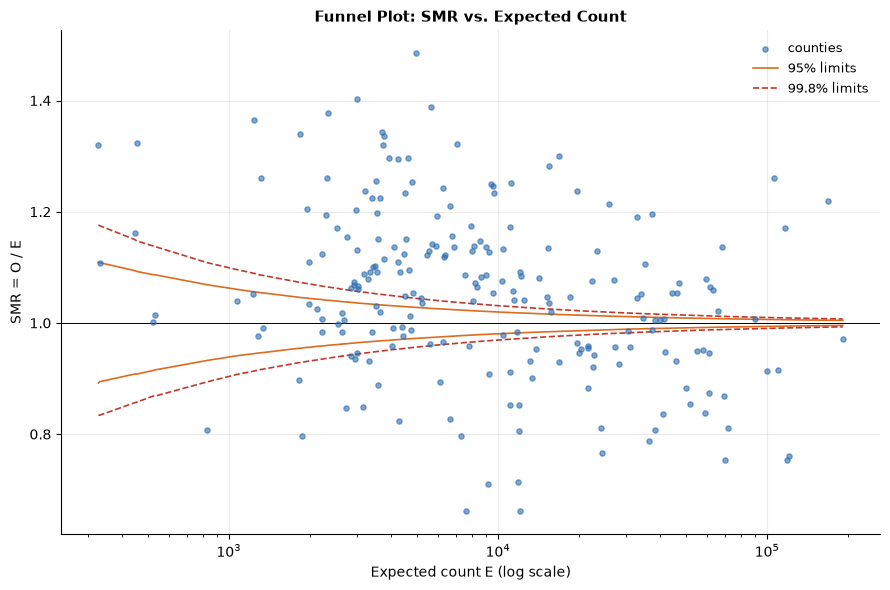

counties outside their OWN 95% control limit: 189 of 217 (87.1%)


In [3]:
raw = smr(O, E)
limits = funnel_limits(E, levels=(0.95, 0.998))

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(E, raw, s=14, color=C["blue"], alpha=0.6, zorder=3, label="counties")
ax.plot(limits["expected"], limits["lo_0.95"], color=C["orange"], lw=1.2, label="95% limits")
ax.plot(limits["expected"], limits["hi_0.95"], color=C["orange"], lw=1.2)
ax.plot(limits["expected"], limits["lo_0.998"], color=C["red"], lw=1.2, ls="--", label="99.8% limits")
ax.plot(limits["expected"], limits["hi_0.998"], color=C["red"], lw=1.2, ls="--")
ax.axhline(1.0, color="k", lw=0.7)
ax.set_xscale("log")
ax.set_xlabel("Expected count E (log scale)")
ax.set_ylabel("SMR = O / E")
ax.set_title("Funnel Plot: SMR vs. Expected Count")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

from scipy import stats as _stats
lo_own = _stats.poisson.ppf(0.025, E) / E
hi_own = _stats.poisson.ppf(0.975, E) / E
outside = (raw < lo_own) | (raw > hi_own)
print(f"counties outside their OWN 95% control limit: {int(outside.sum())} of {len(raw)} ({outside.mean():.1%})")

The control limits visibly narrow (funnel-shaped) as $E$ grows — exactly the $1/\sqrt{E}$ pattern from Section
3. A county near the narrow end of the funnel (large $E$) needs only a small deviation from 1.0 to fall outside
the limits; a county near the wide mouth (small $E$) can sit far from 1.0 and still be entirely consistent with
random Poisson variation around the same true rate as everyone else. Reading the raw scatter without the
funnel overlay risks treating a small county's noisy extreme as if it were as informative as a large county's
equally-far-from-1.0 value — they are not remotely comparable.

A striking 87% of counties fall outside their own 95% Poisson control limit — far more than the 5% pure sampling
noise alone would produce. This is not a sign the funnel plot is wrong; it is evidence of real **overdispersion**:
diabetes prevalence genuinely varies across counties for reasons beyond Poisson sampling variability (Part 2
already found Moran's I = 0.24 in the raw rate — real, spatially structured variation, not noise). The funnel
plot's job is to separate the two sources of spread, not to assume one of them away: Section 3's noise
component still needs to be discounted before the *remaining* variation can be trusted as signal — precisely
the decomposition empirical Bayes performs formally in Chapter 5.5.

***
## 5. Consequence: Unstable Rankings

A concrete demonstration: suppose, hypothetically, **every county had exactly the same true rate**. League
tables (top-10 lists, rankings by rate) would still fluctuate wildly under repeated sampling — purely from
noise — and the fluctuation should depend on population size in exactly the way Section 3 predicts.

In [4]:
rng = np.random.default_rng(1)
true_rate = O.sum() / POP.sum()   # one common rate for every county, by construction

small_idx = np.argsort(POP)[:5]
large_idx = np.argsort(POP)[-5:]
print("5 smallest counties (population):", POP[small_idx].round(0).tolist())
print("5 largest counties  (population):", POP[large_idx].round(0).tolist())

n_sims = 200
rank_std_small, rank_std_large = [], []
for _ in range(n_sims):
    O_sim = rng.poisson(true_rate * POP)
    ranks = pd.Series(O_sim / E).rank().to_numpy()
    rank_std_small.append(ranks[small_idx])
    rank_std_large.append(ranks[large_idx])

rank_std_small = np.std(np.array(rank_std_small), axis=0).mean()
rank_std_large = np.std(np.array(rank_std_large), axis=0).mean()
print(f"\nmean rank standard deviation across {n_sims} simulated resamples (rank out of 217):")
print(f"  5 smallest counties: {rank_std_small:.1f}")
print(f"  5 largest counties : {rank_std_large:.1f}")

5 smallest counties (population): [4444.0, 4508.0, 6055.0, 6188.0, 7082.0]
5 largest counties  (population): [1579085.0, 1605703.0, 1635571.0, 2290044.0, 2591918.0]

mean rank standard deviation across 200 simulated resamples (rank out of 217):
  5 smallest counties: 94.9
  5 largest counties : 24.8


Even though **every county has the identical true rate by construction**, a small county's rank in the league
table bounces around by roughly a *third of the entire table's length* from one random resample to the next;
the largest counties' rank is far more stable. Any "top 10 highest-rate counties" list built from raw rates is,
for the smaller counties on it, close to a random draw — not a ranking of real underlying differences.

***
## 6. Other Consequences

- **False hot spots.** Every method in Part 4 (Gi*, LISA, the scan statistic) is applied to raw rates or counts
  unless explicitly adjusted; a small county's noisy extreme can register as a "hot spot" purely from the
  variance shown here, not a real elevated risk (Part 4, Chapter 4.7, Bridge 2, already previewed this directly
  with this Part's own dataset).
- **Small-cell privacy.** A county reporting a handful of cases out of a small population risks re-identifying
  individuals, particularly for sensitive outcomes — a data-governance concern layered on top of the
  statistical instability, and one reason official statistics agencies suppress small cells regardless of
  whether the resulting rate looks unusual (Chapter 5.10 returns to this).
- **Misleading regionalisation and regression.** Part 3's spatial regression and Part 4's regionalisation both
  treat every observation as equally informative unless population is explicitly included as a weight or
  covariate; a handful of small, noisy counties can disproportionately influence a fitted relationship or a
  region's attribute profile.

***
## 7. The Goal: Borrowing Strength

The fix in both cases to come is the same underlying idea, applied at two different scopes: **use information
from elsewhere to stabilise an area's own noisy estimate**, in proportion to how noisy that estimate actually
is (Section 3's variance, not just population as a rule of thumb).

- **Empirical Bayes (Chapter 5.5)** borrows strength across **all** areas: every county's estimate is pulled
  toward an overall (or covariate-adjusted) mean, with the pull strength set by each area's own expected count.
- **Spatial Bayesian smoothing — BYM (Chapters 5.6–5.7)** borrows strength across **neighbours** specifically:
  an area's estimate is pulled toward its local neighbourhood, respecting real spatial trends rather than
  averaging distant, dissimilar regions together.

Both approaches keep the small-area rate honest about its own uncertainty while still using every county's data
— they do not simply discard small counties, which would waste real information.

***
## 8. Summary and Conclusions

This chapter made the small-area estimation problem concrete, not just asserted.

### What we did

1. Derived and verified $\text{Var}(\text{rate}) \propto 1/\text{population}$ directly: each 10-fold increase
   in population divides the standard error by $\sqrt{10}$.
2. Built a funnel plot on real data, showing the control limits narrow exactly as predicted.
3. Ran a 200-replicate simulation under a **common true rate for every county**, showing the five smallest
   counties' rank fluctuates roughly 4x more than the five largest counties' rank, purely from sampling noise.
4. Reviewed three further consequences: false hot spots (already previewed in Part 4), small-cell privacy, and
   contamination of downstream regression/regionalisation.
5. Named the two remedies Part 5 builds: empirical Bayes (borrow strength globally) and BYM (borrow strength
   from neighbours).

### Practical takeaways

- Never rank or rate-limit small areas without accounting for their expected count — the funnel plot is the
  fastest honest check.
- A "top 10" list of raw rates is dominated by small-population noise unless it has been explicitly adjusted;
  treat it as suspect by default.
- The fix is not to discard small areas — it is to smooth them using information they legitimately share with
  the whole region or their neighbours, which Chapters 5.5–5.7 build.

### Next steps

**Chapter 5.3 (Data and Making the Problem Visible)** prepares the data this Part uses throughout — including
a simulation with a *known* true risk surface, since (as this chapter's own funnel plot shows) the real
diabetes data is not actually sparse enough to make smoothing's benefit dramatic on its own.

***
## 9. Resources

### Textbooks

| Reference | Notes |
|---|---|
| Lawson, A. B. (2018). *Bayesian Disease Mapping* (3rd ed.). CRC Press. | Chapter 2 develops the small-area variance problem in full |
| Waller, L. A. & Gotway, C. A. (2004). *Applied Spatial Statistics for Public Health Data*. Wiley. | Accessible treatment of rate instability and standardisation |

### Key papers

| Paper | Contribution |
|---|---|
| Spiegelhalter, D. J. (2005). Funnel plots for comparing institutional performance. *Statistics in Medicine*, 24, 1185–1202. | Origin of the funnel-plot approach used in Section 4 |
| Gelman, A. & Price, P. N. (1999). All maps of parameter estimates are misleading. *Statistics in Medicine*, 18, 3221–3234. | Classic demonstration of rank instability from raw small-area estimates |

### In this library

| Object | Role |
|---|---|
| `spatialstats.bayes.expected_counts`, `smr` | The raw quantities this chapter's demonstrations are built from |
| `spatialstats.bayes.funnel_limits` | The control-limit overlay used in Section 4 |
| Chapter 5.5 | `eb_gamma_poisson`, `eb_james_stein`, `eb_local` — empirical Bayes, the global-borrowing remedy |
| Chapter 5.6 | `BYM` — the spatial-borrowing remedy |